In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="r3ErAguz5nLW7XElnGIW")
project = rf.workspace("potholesdetection-aq76f").project("detection-potholes-classes")
version = project.version(7)
dataset = version.download("yolov8")
                

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.8/91.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 102.5 MB/s eta 0:00:0000:01
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.22.1 requires google-cloud-bigquery-s


Extracting Dataset Version Zip to Detection-Potholes-Classes-7 in yolov8:: 100%|██████████| 3144/3144 [00:00<00:00, 7008.54it/s]


In [2]:
import os

os.listdir(dataset.location)


['valid',
 'data.yaml',
 'README.roboflow.txt',
 'train',
 'test',
 'README.dataset.txt']

In [3]:
with open(f"{dataset.location}/data.yaml", "r") as f:
    print(f.read())


names:
- medium-pothole
- risk-pothole
- safe-pothole
nc: 3
roboflow:
  license: CC BY 4.0
  project: detection-potholes-classes
  url: https://universe.roboflow.com/potholesdetection-aq76f/detection-potholes-classes/dataset/7
  version: 7
  workspace: potholesdetection-aq76f
test: ../test/images
train: ../train/images
val: ../valid/images



In [4]:
!pip install ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.5 MB/s eta 0:00:00a 0:00:01


In [5]:
from ultralytics import YOLO


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [6]:
model = YOLO("yolov8n.pt")

model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=15,
    imgsz=640,
    batch=16
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/Detection-Potholes-Classes-7/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f61d722f830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [9]:
!ls "/kaggle/working/runs/detect/train"

args.yaml			 results.csv	     val_batch0_labels.jpg
BoxF1_curve.png			 results.png	     val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg    val_batch1_labels.jpg
BoxPR_curve.png			 train_batch1.jpg    val_batch1_pred.jpg
BoxR_curve.png			 train_batch2.jpg    val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch345.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch346.jpg  weights
labels.jpg			 train_batch347.jpg


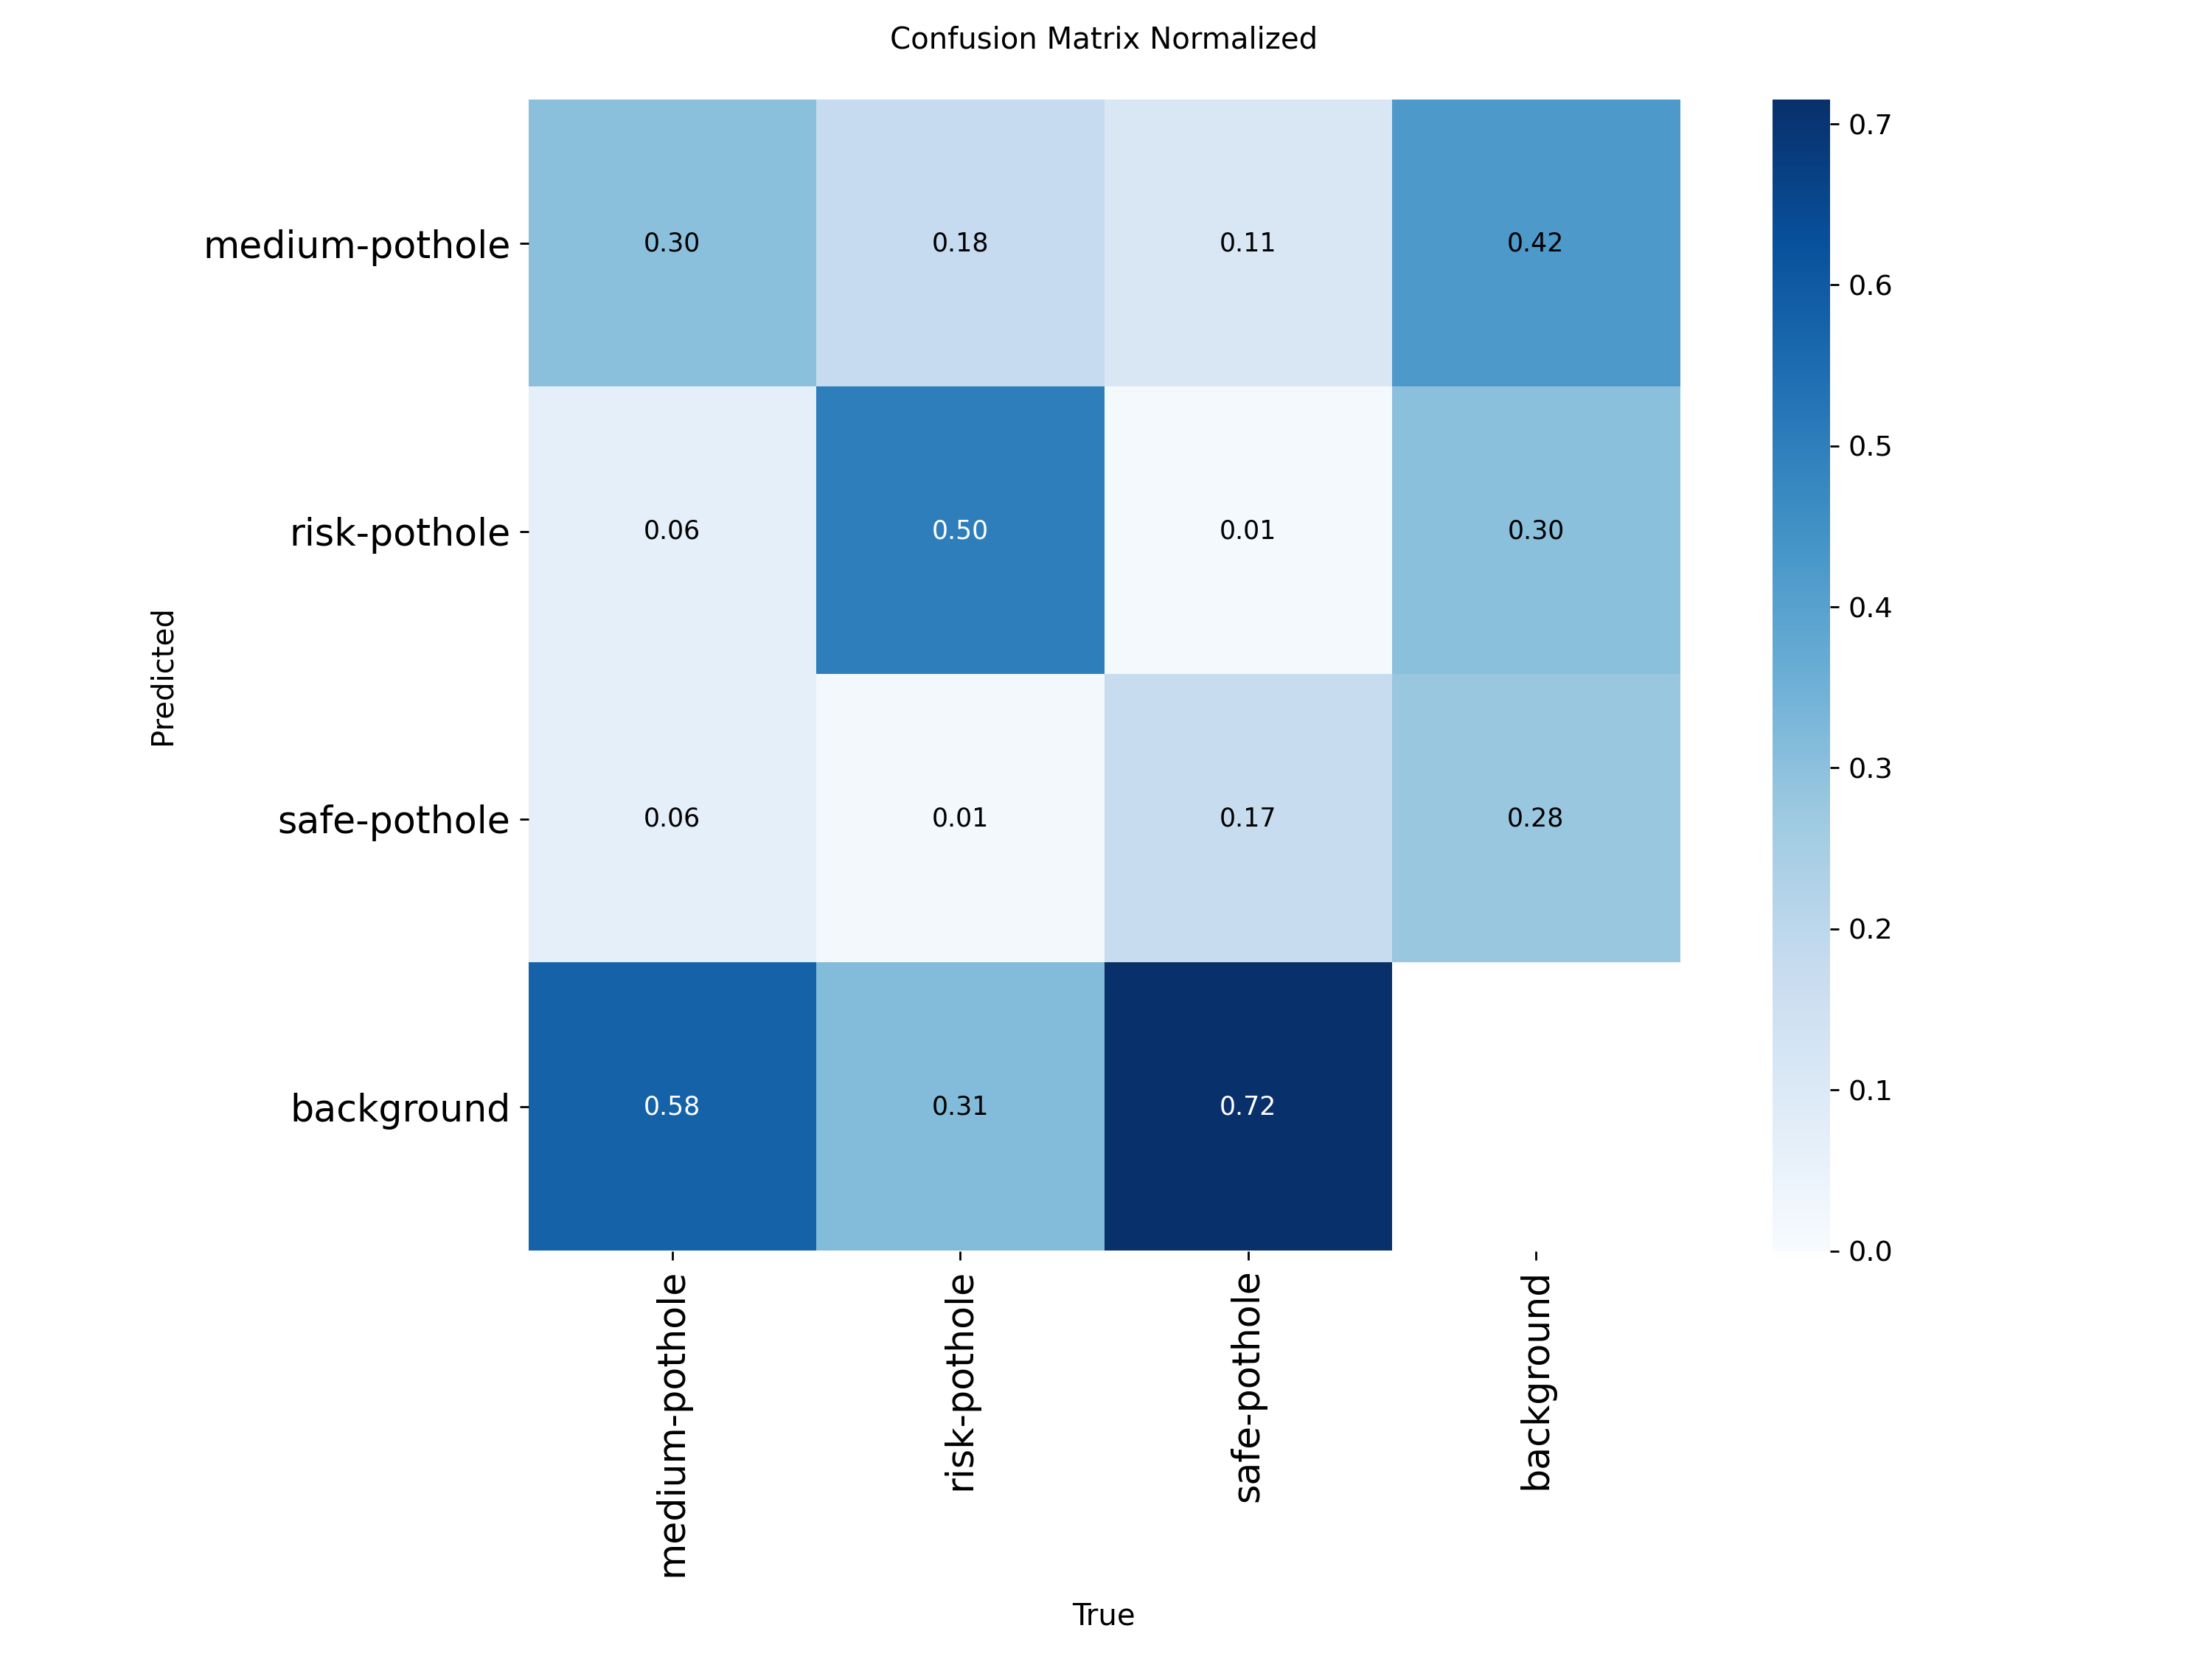

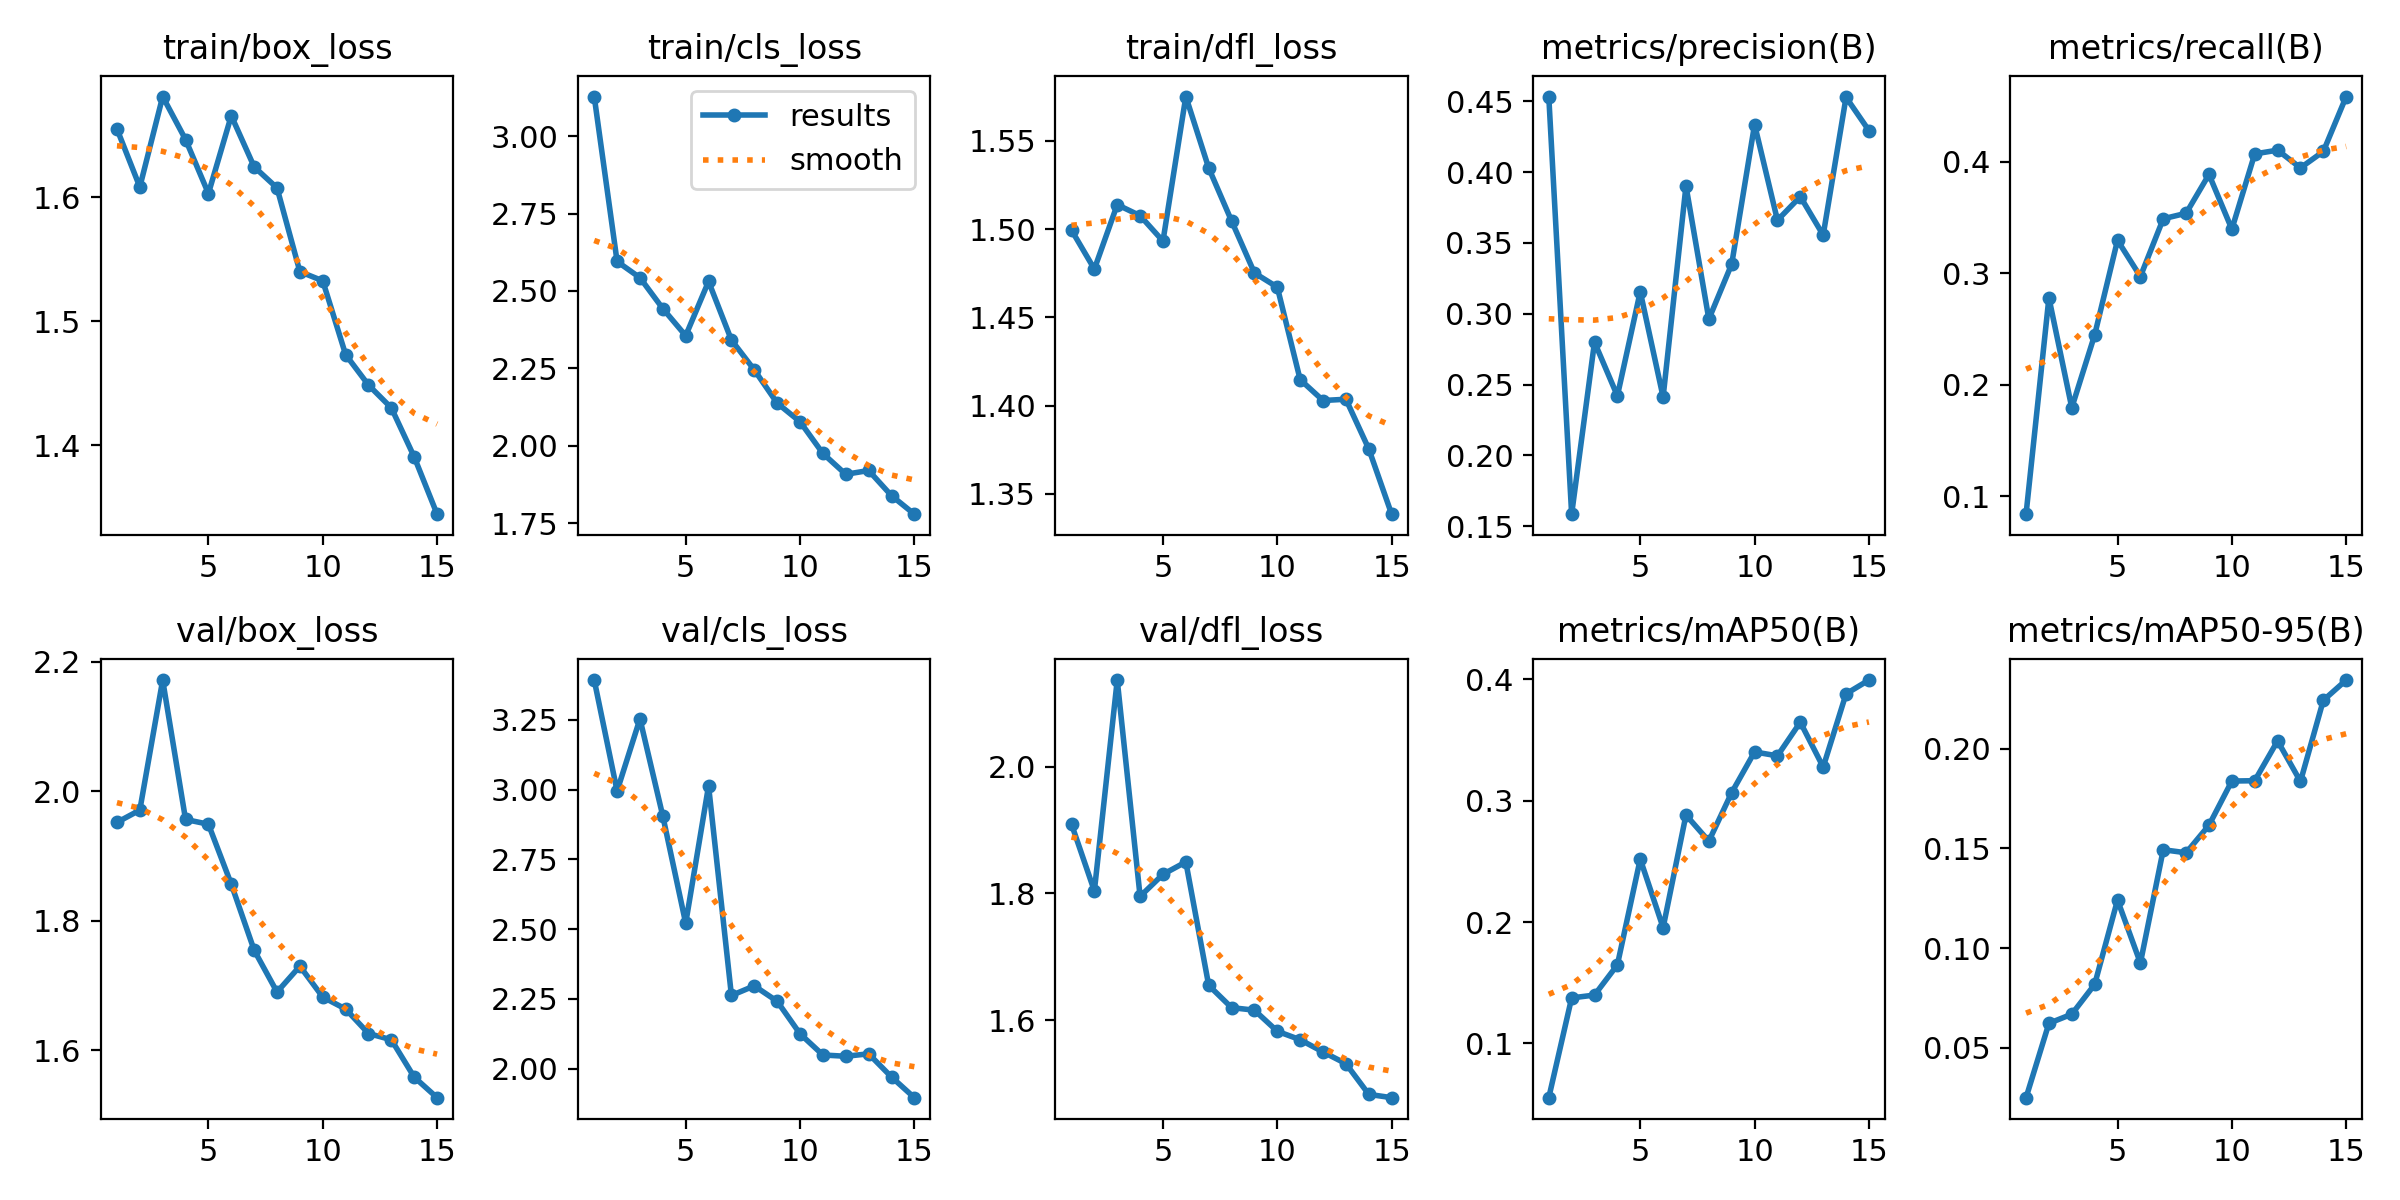

In [20]:
from IPython.display import Image, display

result_path ="/kaggle/working/runs/detect/train"
display(Image(filename =f"{result_path}/confusion_matrix_normalized.png"))
display(Image(filename =f"{result_path}/results.png"))

In [25]:
best_path = "/kaggle/working/runs/detect/train/weights/best.pt"

!yolo detect predict \
model={best_path} \
source="/kaggle/input/potholes-projecte-video/second_Pothole video.mp4" \
conf=0.25 \
save=True


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs

video 1/1 (frame 1/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 46.6ms
video 1/1 (frame 2/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 6.3ms
video 1/1 (frame 3/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 5.5ms
video 1/1 (frame 4/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 6.5ms
video 1/1 (frame 5/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 2 medium-potholes, 5.6ms
video 1/1 (frame 6/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 5.7ms
video 1/1 (frame 7/821) /kaggle/input/potholes-projecte-video/second_Pothole video.mp4: 640x384 1 medium-pothole, 5